<a href="https://colab.research.google.com/github/RegmiYogesh/Object_Centric_Patch-_sampling/blob/main/Pond_Sliding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import sys
from osgeo import gdal, osr
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import glob
from PIL import Image
import random
from tensorflow import keras
%matplotlib inline

In [2]:

from PIL import Image
from tensorflow.python.keras import Model
from tensorflow.python.keras.layers import Conv2D, Input, MaxPooling2D, Conv2DTranspose, Concatenate, Dropout
from tensorflow.keras import layers, models
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.optimizers import Adam

In [3]:
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, BatchNormalization, Activation, Dense, Dropout
from tensorflow.keras.layers import MaxPooling2D, GlobalMaxPool2D
from tensorflow.keras.layers import Conv2D, Conv2DTranspose
from tensorflow.keras.layers import concatenate, add
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from tensorflow.keras.metrics import Recall, Precision
from sklearn.model_selection import train_test_split

In [4]:
train_image_dir = sorted(glob.glob(r"G:\yogesh\Pond_data\Centroid\images\*.tif"))
train_mask_dir = sorted(glob.glob(r"G:\yogesh\Pond_data\Centroid\labels\*.tif"))

In [5]:
# DOUBLE CHECK: Do the counts match?
print(f"Total Images: {len(train_image_dir)}")
print(f"Total Masks: {len(train_mask_dir)}")

Total Images: 792
Total Masks: 792


In [6]:
print(len(train_image_dir))

792


Converting the training files into numpy array

In [7]:
X = []
Y = []

for image_path, mask_path in zip(train_image_dir, train_mask_dir):
    # Load image using GDAL
    img_ds = gdal.Open(image_path)
    img = img_ds.ReadAsArray()
    # Changed from img = img[:3, :, :] to img = img[:4, :, :] to match model input of 4 channels
    img = img[:4, :, :]
    img = img.transpose(1, 2, 0)  # Transpose to (height, width, channels)
    X.append(img)

    # Load mask using GDAL
    mask_ds = gdal.Open(mask_path)
    mask = mask_ds.ReadAsArray()
    Y.append(mask)

# Convert lists to NumPy arrays
X = np.array(X)
Y = np.array(Y)

C:\ProgramData\miniconda3\envs\ponds\Lib\site-packages\osgeo\gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


In [8]:
# 1. Split off the 70% Training set
train_xx, temp_xx, train_yy, temp_yy = train_test_split(
    X, Y, train_size=0.70, random_state=42
)

# 2. Split the remaining 30% into Validation (20%) and Test (10%)
# Since 20% is 2/3 of 30%, we use test_size=0.33 (1/3) for the test set
valid_xx, test_xx, valid_yy, test_yy = train_test_split(
    temp_xx, temp_yy, test_size=0.33, random_state=42
)

print(f"Training:   {train_xx.shape[0]} images (70%)")
print(f"Validation: {valid_xx.shape[0]} images (20%)")
print(f"Testing:    {test_xx.shape[0]} images (10%)")

Training:   554 images (70%)
Validation: 159 images (20%)
Testing:    79 images (10%)


In [9]:
train_yy=np.array(train_yy).astype(int)
test_yy=np.array(test_yy).astype(int)
valid_yy=np.array(valid_yy).astype(int)

In [10]:
num_train = len(train_xx)
print (num_train)

554


In [11]:
#random image number
img_num = random.randint(0, num_train-1)
img_num

0

Plotting the image and mask

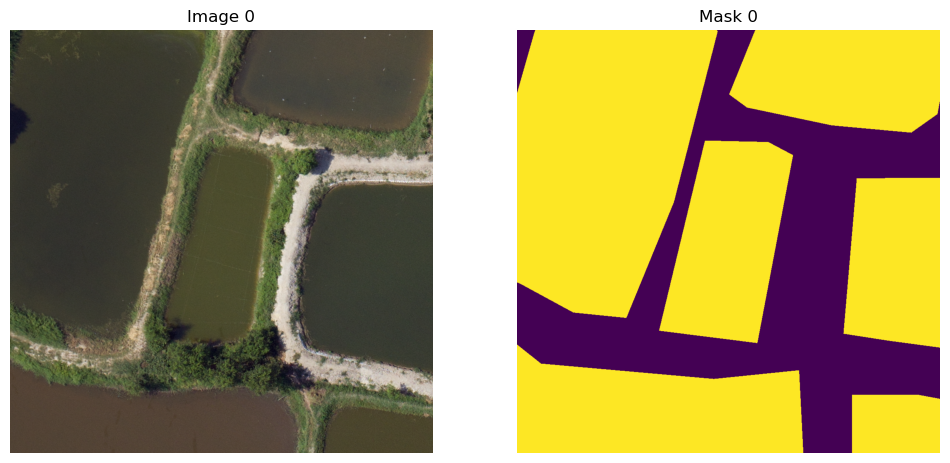

In [12]:
plt.figure(figsize=(12, 6))

image_to_plot = train_xx[img_num]
mask_to_plot = train_yy[img_num]

# For image visualization, select the first 3 channels and normalize for better contrast.
display_image = image_to_plot[:, :, :3]

# Ensure display_image is float for normalization
display_image = display_image.astype(np.float32)
for i in range(display_image.shape[-1]):
    min_val = display_image[:, :, i].min()
    max_val = display_image[:, :, i].max()
    if (max_val - min_val) > 0: # Avoid division by zero
        display_image[:, :, i] = (display_image[:, :, i] - min_val) / (max_val - min_val)

plt.subplot(1, 2, 1)
plt.title(f"Image {img_num}")
plt.imshow(display_image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Mask {img_num}")
plt.imshow(mask_to_plot) # Masks are typically grayscale
plt.axis('off')

plt.show()

In [13]:
import numpy as np

def scale_channels(data):
    # Create an empty array to hold the scaled data
    scaled_data = np.zeros_like(data, dtype=np.float32)

    # Scale each of the 4 channels independently
    for i in range(4):
        ch_min = np.min(data[..., i])
        ch_max = np.max(data[..., i])

        # Avoid division by zero if a channel is empty
        if ch_max - ch_min != 0:
            scaled_data[..., i] = (data[..., i] - ch_min) / (ch_max - ch_min)
        else:
            scaled_data[..., i] = 0.0

    return scaled_data

# Apply the scaling
train_xx = scale_channels(train_xx)
valid_xx = scale_channels(valid_xx)
test_xx = scale_channels(test_xx)

print(f"New Training Range: {np.min(train_xx)} to {np.max(train_xx)}")

New Training Range: 0.0 to 1.0


In [ ]:
print(f"Min value of train_xx: {np.min(train_xx)}")
print(f"Max value of train_xx: {np.max(train_xx)}")
print(f"Min value of test_xx: {np.min(test_xx)}")
print(f"Max value of test_xx: {np.max(test_xx)}")
print(f"Min value of valid_xx: {np.min(valid_xx)}")
print(f"Max value of valid_xx: {np.max(valid_xx)}")

Min value of train_xx: 0.0
Max value of train_xx: 1.0
Min value of test_xx: 0.0
Max value of test_xx: 1.0
Min value of valid_xx: 0.0
Max value of valid_xx: 1.0


Validation Image 0 has 0 cotton pixels.
Validation Image 1 has 0 cotton pixels.
Validation Image 2 has 248220 cotton pixels.
Validation Image 3 has 256791 cotton pixels.
Validation Image 4 has 80887 cotton pixels.
Validation Image 5 has 179833 cotton pixels.
Validation Image 6 has 0 cotton pixels.
Validation Image 7 has 40440 cotton pixels.
Validation Image 8 has 127590 cotton pixels.
Validation Image 9 has 181731 cotton pixels.


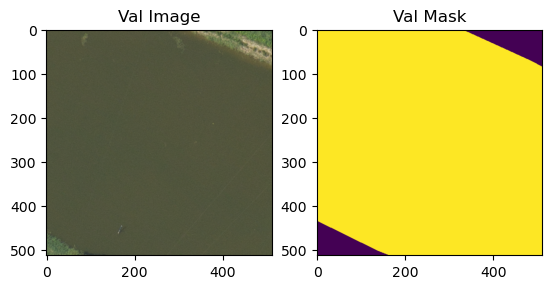

In [ ]:
import matplotlib.pyplot as plt

# Check if validation masks actually contain cotton (1s)
for i in range(10):
    has_cotton = np.sum(valid_yy[i])
    print(f"Validation Image {i} has {has_cotton} cotton pixels.")

# Visualize one pair to be safe
plt.subplot(1,2,1)
plt.imshow(valid_xx[2][:,:,:3]) # Show RGB
plt.title("Val Image")
plt.subplot(1,2,2)
plt.imshow(valid_yy[2]) # Show Mask
plt.title("Val Mask")
plt.show()

Custom Metrics and Loss Logic


In [ ]:
from tensorflow.keras import backend as K
from tensorflow.keras.losses import binary_crossentropy
import tensorflow as tf

def dice_loss(y_true, y_pred):
    smooth = 1.0
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    # Using axis=(1,2,3) ensures we reduce across spatial and channel dimensions while keeping batch rank
    intersection = tf.reduce_sum(y_true * y_pred, axis=(1, 2, 3))
    sum_true = tf.reduce_sum(y_true, axis=(1, 2, 3))
    sum_pred = tf.reduce_sum(y_pred, axis=(1, 2, 3))
    dice = (2. * intersection + smooth) / (sum_true + sum_pred + smooth)
    return 1. - tf.reduce_mean(dice)

def dice_bce_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred, axis=(1, 2, 3))
    fp = tf.reduce_sum((1 - y_true) * y_pred, axis=(1, 2, 3))
    fn = tf.reduce_sum(y_true * (1 - y_pred), axis=(1, 2, 3))
    score = (2 * tp) / (2 * tp + fp + fn + tf.keras.backend.epsilon())
    return tf.reduce_mean(score)

Model Preparation

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Clear the backend to avoid variable creation errors
tf.keras.backend.clear_session()

filt = [16,32,64,128,256]

def downward_conv(inputTensor, numFilters, act='relu', p='same'):
    down = layers.Conv2D(filters=numFilters, kernel_size=(3,3), strides=1, padding=p)(inputTensor)
    down = layers.BatchNormalization()(down)
    down = layers.Activation(act)(down)
    down = layers.Dropout(0.15)(down)
    down = layers.Conv2D(filters=numFilters, kernel_size=(3,3), strides=1, padding=p)(down)
    down = layers.BatchNormalization()(down)
    down = layers.Activation(act)(down)
    down = layers.Dropout(0.15)(down)
    pool = layers.MaxPool2D(pool_size=(2,2), strides=(2,2))(down)
    return down, pool

def bottleneck(inputTensor, numFilters, act='relu', p='same'):
    mid = layers.Conv2D(filters=numFilters, kernel_size=(3,3), strides=1, padding=p)(inputTensor)
    mid = layers.BatchNormalization()(mid)
    mid = layers.Activation(act)(mid)
    mid = layers.Dropout(0.15)(mid)
    mid = layers.Conv2D(filters=numFilters, kernel_size=(3,3), strides=1, padding=p)(mid)
    mid = layers.BatchNormalization()(mid)
    mid = layers.Activation(act)(mid)
    mid = layers.Dropout(0.15)(mid)
    return mid

def upward_conv(inputTensor, correspondingDownTensor, numFilters, act='relu', p='same'):
    up = layers.Conv2DTranspose(filters=numFilters, kernel_size=(2,2), strides=(2,2), padding=p)(inputTensor)
    up = layers.concatenate([correspondingDownTensor, up], axis=-1)
    up = layers.BatchNormalization()(up)
    up = layers.Activation(act)(up)
    up = layers.Conv2D(filters=numFilters, kernel_size=(3,3), strides=1, padding=p)(up)
    up = layers.BatchNormalization()(up)
    up = layers.Activation(act)(up)
    up = layers.Dropout(0.15)(up)
    up = layers.Conv2D(filters=numFilters, kernel_size=(3,3), strides=1, padding=p)(up)
    up = layers.BatchNormalization()(up)
    up = layers.Activation(act)(up)
    up = layers.Dropout(0.15)(up)
    return up

def unet():
    start = layers.Input(shape=(512, 512, 4))
    down_step1, pool1 = downward_conv(start, filt[0])
    down_step2, pool2 = downward_conv(pool1, filt[1])
    down_step3, pool3 = downward_conv(pool2, filt[2])
    down_step4, pool4 = downward_conv(pool3, filt[3])

    middle = bottleneck(pool4, filt[4])

    up_step1 = upward_conv(middle, down_step4, filt[3])
    up_step2 = upward_conv(up_step1, down_step3, filt[2])
    up_step3 = upward_conv(up_step2, down_step2, filt[1])
    up_step4 = upward_conv(up_step3, down_step1, filt[0])

    output = layers.Conv2D(filters=1, kernel_size=(1,1), activation='sigmoid', padding='same')(up_step4)

    model = models.Model(inputs=start, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
        loss=dice_bce_loss,
        metrics=[
            tf.keras.metrics.BinaryIoU(threshold=0.5, name="iou"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            f1_score
        ]
    )
    return model

model = unet()

In [ ]:

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 512, 512, 4)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_57 (Conv2D)            │ (None, 512, 512, 16)      │             592 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_66        │ (None, 512, 512, 16)      │              64 │ conv2d_57[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_66 (Activation)    │ (None, 512, 512, 16)      │               0 │ batch_normalization_66[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_54 (Dropout)          │ (None, 512, 512, 16)      │               0 │ activation_66[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_58 (Conv2D)            │ (None, 512, 512, 16)      │           2,320 │ dropout_54[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_67        │ (None, 512, 512, 16)      │              64 │ conv2d_58[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_67 (Activation)    │ (None, 512, 512, 16)      │               0 │ batch_normalization_67[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_55 (Dropout)          │ (None, 512, 512, 16)      │               0 │ activation_67[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_12              │ (None, 256, 256, 16)      │               0 │ dropout_55[0][0]           │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_59 (Conv2D)            │ (None, 256, 256, 32)      │           4,640 │ max_pooling2d_12[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_68        │ (None, 256, 256, 32)      │             128 │ conv2d_59[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_68 (Activation)    │ (None, 256, 256, 32)      │               0 │ batch_normalization_68[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_56 (Dropout)          │ (None, 256, 256, 32)      │               0 │ activation_68[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_60 (Conv2D)            │ (None, 256, 256, 32)      │           9,248 │ dropout_56[0][0]           │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 1,949,057 (7.44 MB)

 Trainable params: 1,945,153 (7.42 MB)

 Non-trainable params: 3,904 (15.25 KB)

Training Callbacks & Execution

In [ ]:
print(f"Shape of train_xx before model.fit: {train_xx.shape}")
print(f"Shape of valid_xx before model.fit: {valid_xx.shape}")

# 1. Define Callbacks for stability and "locking in" best results
import os

# Ensure directory exists
os.makedirs(r'D:\Cotton_Detection', exist_ok=True)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=4,
        mode='min',
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        mode='min',
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=r'D:\Cotton_Detection\best_cotton_v214.h5',
        monitor='val_iou',
        mode='max',
        save_best_only=True
    )
]




Shape of train_xx before model.fit: (529, 512, 512, 4)
Shape of valid_xx before model.fit: (152, 512, 512, 4)


In [ ]:
# Ensure labels have the channel dimension (batch, height, width, 1)
# Use conditional expansion to avoid 'Creating variables' error from repeated runs
if train_yy.ndim == 3:
    train_yy = np.expand_dims(train_yy, axis=-1)
if valid_yy.ndim == 3:
    valid_yy = np.expand_dims(valid_yy, axis=-1)
if test_yy.ndim == 3:
    test_yy = np.expand_dims(test_yy, axis=-1)

print(f"Final Label Shape: {train_yy.shape}")

# 2. Run the training with callbacks
history = model.fit(
    train_xx,
    train_yy,
    validation_data=(valid_xx, valid_yy),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
    shuffle=True
)

# 3. Save the final model
model.save(r'G:\yogesh\2112026\PondDetection\Ponds.h5')
print("Model training complete and saved successfully.")

Final Label Shape: (529, 512, 512, 1)
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - f1_score: 0.6186 - iou: 0.3675 - loss: 1.2179 - precision: 0.6715 - recall: 0.7146 

17/17 ━━━━━━━━━━━━━━━━━━━━ 312s 18s/step - f1_score: 0.6383 - iou: 0.3980 - loss: 1.1716 - precision: 0.6856 - recall: 0.7631 - val_f1_score: 0.6687 - val_iou: 0.4203 - val_loss: 1.2230 - val_precision: 0.6523 - val_recall: 0.9682 - learning_rate: 2.0000e-04
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 294s 17s/step - f1_score: 0.6961 - iou: 0.5448 - loss: 0.9859 - precision: 0.7697 - recall: 0.8626 - val_f1_score: 0.6688 - val_iou: 0.3023 - val_loss: 1.1853 - val_precision: 0.6043 - val_recall: 1.0000 - learning_rate: 2.0000e-04
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 312s 18s/step - f1_score: 0.7086 - iou: 0.6530 - loss: 0.8596 - precision: 0.8464 - recall: 0.8650 - val_f1_score: 0.6688 - val_iou: 0.3021 - val_loss: 1.1404 - val_precision: 0.6043 - val_recall: 1.0000 - learning_rate: 2.0000e-04
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 303s 18s/step - f1_score: 0.7111 - iou: 0.6965 - loss: 0.7954 - precision: 0.8824 - recall: 0.8625 - val_f1_score: 0.6688 - val_iou: 0.3021 - val_loss: 1.1179 -

Model training complete and saved successfully.


In [ ]:
import pandas as pd
import os

# Convert the history dictionary to a pandas DataFrame
history_df = pd.DataFrame(history.history)

# Define the output directory and filename for the CSV
output_dir = r"D:\Sandeep\CottonDetection\Model performance graphs"
os.makedirs(output_dir, exist_ok=True)
csv_filepath = os.path.join(output_dir, "training_history.csv")

# Save the DataFrame to a CSV file
history_df.to_csv(csv_filepath, index=False)

print(f"Training history exported successfully to: {csv_filepath}")

Visualization grpahs

In [ ]:
import matplotlib.pyplot as plt
import os

def plot_all_metrics(history, output_dir=r"D:\Sandeep\CottonDetection\Model performance graphs"):
    # Define the metrics we want to plot (based on your model.compile names)
    metrics_to_plot = [
        ('iou', 'Intersection over Union (IoU)'),
        ('f1_score', 'F1-Score (Dice Coefficient)'),
        ('precision', 'Precision (Exactness)'),
        ('recall', 'Recall (Completeness)'),
        ('loss', 'Loss'),
        ('lr', 'Learning Rate')
    ]

    epochs = range(1, len(history.history['loss']) + 1)

    # Create a 3x2 subplot grid for 6 plots
    fig, axs = plt.subplots(3, 2, figsize=(16, 18))
    axs = axs.ravel() # Flatten the 3x2 grid into a list for easy looping

    for i, (metric_key, title) in enumerate(metrics_to_plot):
        # Plot Training Metric
        if metric_key in history.history:
            axs[i].plot(epochs, history.history[metric_key], 'b', label=f'Train {metric_key.replace("_"," ").title()}')

        # Plot Validation Metric (Keras adds 'val_' prefix)
        val_key = 'val_' + metric_key
        if val_key in history.history:
            axs[i].plot(epochs, history.history[val_key], 'r', label=f'Val {metric_key.replace("_"," ").title()}')

        axs[i].set_title(title, fontsize=14, fontweight='bold')
        axs[i].set_xlabel('Epochs')
        axs[i].set_ylabel('Score' if metric_key not in ['loss', 'lr'] else 'Value')
        # Set legend location based on metric_key
        if metric_key in ['loss', 'lr']:
            axs[i].legend(loc='upper right')
        else:
            axs[i].legend(loc='lower right')
        axs[i].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

    # Export the graphs
    os.makedirs(output_dir, exist_ok=True)
    for i, (metric_key, title) in enumerate(metrics_to_plot):
        plt.figure(figsize=(10, 6))
        if metric_key in history.history:
            plt.plot(epochs, history.history[metric_key], 'b', label=f'Train {metric_key.replace("_"," ").title()}')
        val_key = 'val_' + metric_key
        if val_key in history.history:
            plt.plot(epochs, history.history[val_key], 'r', label=f'Val {metric_key.replace("_"," ").title()}')
        plt.title(title, fontsize=14, fontweight='bold')
        plt.xlabel('Epochs')
        plt.ylabel('Score' if metric_key not in ['loss', 'lr'] else 'Value')
        # Set legend location for exported graphs
        if metric_key in ['loss', 'lr']:
            plt.legend(loc='upper right')
        else:
            plt.legend(loc='lower right')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.savefig(os.path.join(output_dir, f'{metric_key}_plot.png'))
        plt.close() # Close the figure to free up memory
    print(f"All performance graphs exported to: {output_dir}")

# Run the plotting function and export graphs
plot_all_metrics(history)

In [ ]:
# --- NEW CELL: THRESHOLD CALIBRATION AND PRECISION-RECALL CURVE ---

from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
import os # Import os for directory creation and path joining

print("🛰️ Finding the optimal threshold for cotton detection...")

# 1. Get raw probability predictions for the test set
y_pred_probs = model.predict(test_xx, verbose=1).ravel()
y_true = test_yy.ravel()

# 2. Calculate precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_true, y_pred_probs)

# 3. Calculate F1 scores for every threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

# 4. Identify the 'Best' threshold
best_idx = np.argmax(f1_scores)
# Note: thresholds has one less element than precision/recall,
# so we cap the index to avoid bounds errors
best_threshold = thresholds[min(best_idx, len(thresholds)-1)]

print(f"✅ Calibration Complete!")
print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Maximized F1-Score: {f1_scores[best_idx]:.4f}")

# Define the output directory for graphs
output_dir = r"D:\Sandeep\CottonDetection\Model performance graphs"
os.makedirs(output_dir, exist_ok=True)

# 5. Plot the Precision-Recall curve
fig_pr, ax_pr = plt.subplots(figsize=(10, 7))
ax_pr.plot(recall, precision, color='blue', lw=2)
ax_pr.scatter(recall[best_idx], precision[best_idx], marker='o', color='red', zorder=5) # Removed label from scatter
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve')
# Removed ax_pr.legend() as annotation will be used instead
ax_pr.grid(True)

# Annotate the best F1-score and threshold, placed away from the point
annotation_text = f'Optimal Thresh: {best_threshold:.4f}\nMax F1-Score: {f1_scores[best_idx]:.4f}'
ax_pr.annotate(annotation_text,
               xy=(recall[best_idx], precision[best_idx]),
               xytext=(0.5, 0.7),  # Position of the text (x, y) in axes coordinates, moved upwards
               textcoords='axes fraction',
               arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
               fontsize=10,
               bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="b", lw=0.5, alpha=0.8)
              )

# Export the plot to the output directory BEFORE showing it
plt.savefig(os.path.join(output_dir, 'precision_recall_curve.png'))
print(f"Precision-Recall curve exported to: {os.path.join(output_dir, 'precision_recall_curve.png')}")

plt.show() # Display the plot in the notebook
plt.close(fig_pr) # Close the figure to free up memory


Graphs of Model

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf # Ensure tf is imported for tf.squeeze if not already globally available
import os # Import os for directory creation and path joining
import random # Import random for selecting indices

def visualize_cotton_predictions(x_test, y_test, model, best_threshold, num_samples=5, output_folder=r"D:\Sandeep\CottonDetection\Visualizations_on_test"):
    # Select random indices from the test set that contain cotton
    cotton_indices = []
    for idx in range(len(x_test)):
        if np.sum(y_test[idx]) > 0: # Check if the mask contains any cotton (value > 0)
            cotton_indices.append(idx)

    # If there are fewer cotton patches than num_samples, adjust num_samples
    if len(cotton_indices) < num_samples:
        print(f"Warning: Only {len(cotton_indices)} patches with cotton found. Displaying all of them.")
        indices = cotton_indices
    else:
        indices = random.sample(cotton_indices, num_samples)

    # Ensure output directory exists
    os.makedirs(output_folder, exist_ok=True)

    plt.figure(figsize=(15, 5 * len(indices)))

    for i, idx in enumerate(indices):
        # 1. Get the original image (Taking first 3 channels for RGB display)
        img = x_test[idx][:, :, :3]

        # 2. Get Ground Truth Mask
        gt_mask = y_test[idx].squeeze()

        # 3. Get Model Prediction
        # Use x_test[idx] for prediction, which contains all 4 channels
        pred = model.predict(x_test[idx][np.newaxis, ...], verbose=0)
        predicted_mask = tf.squeeze(pred)
        binary_predicted_mask = (predicted_mask.numpy() > best_threshold).astype(np.uint8)

        # Normalize original RGB channels for display (if not already 0-1)
        display_rgb_patch = img.astype(np.float32)
        for channel_idx in range(display_rgb_patch.shape[-1]):
            min_val = display_rgb_patch[:, :, channel_idx].min()
            max_val = display_rgb_patch[:, :, channel_idx].max()
            if (max_val - min_val) > 0:
                display_rgb_patch[:, :, channel_idx] = (display_rgb_patch[:, :, channel_idx] - min_val) / (max_val - min_val)
            else:
                display_rgb_patch[:, :, channel_idx] = 0.0

        # Create a figure for this sample to save with titles
        fig, axs = plt.subplots(1, 3, figsize=(18, 6)) # Adjusted for 3 plots

        # Plotting the original image (left)
        axs[0].set_title(f"Original Patch {idx}")
        axs[0].imshow(display_rgb_patch)
        axs[0].axis('off')

        # Plotting the Ground Truth Mask (middle)
        axs[1].set_title(f"Ground Truth Mask {idx}")
        axs[1].imshow(gt_mask, cmap='Greens')
        axs[1].axis('off')

        # Plotting the Predicted Mask (right)
        axs[2].set_title(f"Predicted Mask {idx}")
        axs[2].imshow(binary_predicted_mask, cmap='Greens')
        axs[2].axis('off')

        plt.tight_layout()
        plt.show() # Display the figure

        # Save the figure to the output folder
        composite_img_path = os.path.join(output_folder, f"viz_sample_{idx}.png")
        fig.savefig(composite_img_path, bbox_inches='tight')
        plt.close(fig) # Close the figure to free memory

    print(f"All {len(indices)} visualizations exported to: {output_folder}")

# Run the visualization with the specified parameters
visualize_cotton_predictions(test_xx, test_yy, model, best_threshold, num_samples=5, output_folder=r"D:\Sandeep\CottonDetection\Visualizations_on_test")

In [ ]:
model = keras.models.load_model(
    r"D:\Cotton_Detection\final_cotton.h5",
    custom_objects={'dice_loss': dice_loss, 'dice_bce_loss': dice_bce_loss, 'f1_score': f1_score}
)

In [ ]:
np.unique(model.predict(test_xx[[20]]))

In [ ]:
#provide a path of large image for prediction
img=gdal.Open(r"D:\Cotton_detection\test image\test.tif")

In [ ]:
transform=img.GetGeoTransform()

In [ ]:
print(transform)

In [ ]:
projection=img.GetProjection()

In [ ]:
spatial_ref = osr.SpatialReference()

In [ ]:
spatial_ref.ImportFromWkt(projection)
bands = [img.GetRasterBand(band+1) for band in range(img.RasterCount)]
listOfArrays = [band.ReadAsArray() for band in bands]
image = np.array(listOfArrays).astype(int)


In [ ]:
#height,width,band
image=image.transpose(1,2,0)

In [ ]:
image.shape

In [ ]:
# Display the image, normalizing the first 3 bands for visualization
# Note: Assuming 'image' is the variable holding the large image data
# and that it's 16-bit as implied by earlier normalization (65535.0)

def scale_rgb_channels(rgb_data):
    # Create an empty array to hold the scaled data
    scaled_rgb_data = np.zeros_like(rgb_data, dtype=np.float32)

    # Scale each of the 3 channels independently
    for i in range(rgb_data.shape[-1]):
        ch_min = np.min(rgb_data[..., i])
        ch_max = np.max(rgb_data[..., i])

        # Avoid division by zero if a channel is constant
        if (ch_max - ch_min) != 0:
            scaled_rgb_data[..., i] = (rgb_data[..., i] - ch_min) / (ch_max - ch_min)
        else:
            scaled_rgb_data[..., i] = 0.0 # Or leave as is if all values are the same

    return scaled_rgb_data

# Define a downsample factor for visualization
downsample_factor = 5 # Adjust this value as needed, e.g., 2, 5, 10

# Select the first 3 bands for RGB display and downsample it
rgb_image_downsampled = image[::downsample_factor, ::downsample_factor, :3]

# Convert to float for normalization (used for alpha channel as well)
display_image_rgba = rgb_image_downsampled.astype(np.float32)

# Normalize the RGB channels using the custom scaling function
normalized_rgb = scale_rgb_channels(display_image_rgba)

# Create an alpha channel: 0 for no-data (0), 1 for data
# Check the first band of the float32 image for data presence
alpha_channel = np.where(display_image_rgba[:, :, 0] > 0, 1.0, 0.0)

# Stack RGB and alpha channels
final_display_image = np.dstack((normalized_rgb, alpha_channel))

plt.figure(figsize=(10, 10))
plt.imshow(final_display_image)
plt.title("Normalized RGB Image with Transparent No-Data")
plt.axis('off')
plt.show()

In [ ]:
# Slice the image into 256 x 256 patches for prediction.
import pandas as pd
# Some variables.
patch_size = 256
overlap = 0.5

height, width, bands = image.shape
im_list, name_list, pos_list = [], [], []

pos_columns = ['name', 'xmin', 'ymin', 'patch_size', 'im_x', 'im_y']

seen_coords = set()

# Iterate through image and bin it up appropriately.
for x in range(0, width - 1, int(patch_size * (1 - overlap))):          # In this case, the stride is approx. 205 pixels.
    for y in range(0, height - 1, int(patch_size * (1 - overlap))):     # Same as above.

        xmin = min(x, width - patch_size)
        ymin = min(y, height - patch_size)
        coords = (xmin, ymin)

        # check if we've already seen these coords
        if coords in seen_coords:
            # print ("coords already encountered (xmin, ymin):", coords)
            continue
        else:
            seen_coords.add(coords)

        # check if we screwed up binning
        if (xmin + patch_size > width) or (ymin + patch_size > height):
            print ("Oops. Improperly binned image.")
            continue

        # get image cutout
        im_cutout = image[ymin:ymin + patch_size, xmin:xmin + patch_size]

        # set slice name
        name = 'patch_x' + str(xmin) + '_y' + str(ymin) + '_sz' + str(patch_size) + '_w' + str(width) + '_h' + str(height)

        pos = [name, xmin, ymin, patch_size, width, height]

        # add to arrays
        name_list.append(name)
        im_list.append(im_cutout)
        pos_list.append(pos)

# convert to np arrays
name_out_arr = np.array(name_list)
im_out_arr = np.array(im_list)
pred_array = im_out_arr

# create position datataframe
df_pos = pd.DataFrame(pos_list, columns=pos_columns)
df_pos.index = np.arange(len(df_pos))

In [ ]:
print(f"Min pixel value in image: {np.min(image)}")
print(f"Max pixel value in image: {np.max(image)}")


In [ ]:
len(pred_array)

In [ ]:
#Prediction
# Using the optimal threshold found during calibration
threshold = best_threshold

# Initialize an empty list to store predictions from each batch
all_predictions = []

# Define batch size for iterating through pred_array
batch_size = 32 # Adjust as needed based on available memory

# Manually iterate through pred_array in batches
for i in range(0, len(pred_array), batch_size):
    batch_start = i
    batch_end = min(i + batch_size, len(pred_array))
    current_batch = pred_array[batch_start:batch_end]

    # Normalize the current batch using the same function as training data
    normalized_batch = scale_channels(current_batch) # Use the custom scaling function

    # Perform prediction on the current batch
    batch_pred = model.predict(normalized_batch, verbose=0) # verbose=0 to suppress per-batch output
    all_predictions.append(batch_pred)

# Concatenate predictions from all batches
pred_test = np.concatenate(all_predictions, axis=0)


In [ ]:
#Change the threshold to the optimal value found during calibration
threshold = best_threshold
predictions = (pred_test > threshold).astype(np.uint8)


In [ ]:
import random
import tensorflow as tf # Ensure tf is imported for tf.squeeze if not already globally available
import os
import numpy as np # Ensure numpy is imported
import matplotlib.pyplot as plt # Ensure matplotlib is imported

num_samples = 10 # Number of random patches to visualize

# Find indices of patches in the test set that contain cotton
cotton_indices = []
for idx in range(len(test_xx)):
    if np.sum(test_yy[idx]) > 0: # Check if the mask contains any cotton (value > 0)
        cotton_indices.append(idx)

# If there are fewer cotton patches than num_samples, adjust num_samples
if len(cotton_indices) < num_samples:
    print(f"Warning: Only {len(cotton_indices)} patches with cotton found. Displaying all of them.")
    indices = cotton_indices
else:
    indices = random.sample(cotton_indices, num_samples)

# Define output folder for saving images
output_export_folder = r"D:\Sandeep\CottonDetection\Visualizations_on_new_img"
os.makedirs(output_export_folder, exist_ok=True)

for i, img_num in enumerate(indices):
    # Get the original image patch
    original_patch = test_xx[img_num]

    # Get the predicted mask
    pred = model.predict(original_patch[np.newaxis, ...], verbose=0)
    predicted_mask = tf.squeeze(pred)
    binary_predicted_mask = (predicted_mask.numpy() > best_threshold).astype(np.uint8)

    # Normalize original RGB channels for display
    display_rgb_patch = original_patch[:, :, :3].astype(np.float32)
    for channel_idx in range(display_rgb_patch.shape[-1]):
        min_val = display_rgb_patch[:, :, channel_idx].min()
        max_val = display_rgb_patch[:, :, channel_idx].max()
        if (max_val - min_val) > 0:
            display_rgb_patch[:, :, channel_idx] = (display_rgb_patch[:, :, channel_idx] - min_val) / (max_val - min_val)
        else:
            display_rgb_patch[:, :, channel_idx] = 0.0

    # Convert binary predicted mask to RGB (Green for cotton, White for non-cotton)
    green_color_rgb = np.array([0.0, 1.0, 0.0])  # Pure green (normalized 0-1)
    white_color_rgb = np.array([1.0, 1.0, 1.0])  # Pure white (normalized 0-1)

    pred_display_rgb = np.zeros_like(display_rgb_patch, dtype=np.float32)
    pred_display_rgb[binary_predicted_mask == 1] = green_color_rgb
    pred_display_rgb[binary_predicted_mask == 0] = white_color_rgb

    # Create a figure for this sample to save with titles
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    # Plotting the original image (left)
    axs[0].set_title(f"Original Patch {img_num}")
    axs[0].imshow(display_rgb_patch)
    axs[0].axis('off')

    # Plotting the predicted mask (right) with green/white coloring
    axs[1].set_title(f"Predicted Mask {img_num}")
    axs[1].imshow(pred_display_rgb) # Use the green/white RGB mask
    axs[1].axis('off')

    plt.tight_layout()
    plt.show() # Display the figure

    # Save the figure (which includes titles) to the folder
    composite_img_path = os.path.join(output_export_folder, f"viz_original_vs_predicted_{img_num}.png")
    fig.savefig(composite_img_path, bbox_inches='tight')
    plt.close(fig) # Close the figure to free memory

print(f"Exported images to: {output_export_folder}")

In [ ]:
# Rebuild the predictions into a single image.

# For a dataframe of image positions (df_pos), and the tiles of that image
# (im_arr), reconstruct the image.

# Create numpy zeros of appropriate shape.
empty_img = np.zeros((height, width, 1))

# Create another zero array to record where pixels are overlaid.
overlay_count = np.zeros((height, width, 1))

# Iterate through patches.
for index, item in df_pos.iterrows():

    # Grab values for each row / patch.
    [name, xmin, ymin, patch_slice, im_x, im_y] = item

    # Grab the right patch.
    img_slice = predictions[index]

    x0, x1 = xmin, xmin + patch_size
    y0, y1 = ymin, ymin + patch_size

    # Add img_slice to empty_img.
    empty_img[y0:y1, x0:x1] += img_slice

    # Update count of overlapping pixels.
    overlay_count[y0:y1, x0:x1] += np.ones((patch_size, patch_size, 1))

rebuilt_img = np.divide(empty_img, overlay_count)

In [ ]:
# Threshold predictions using the optimal threshold.
binary = np.where(tf.squeeze(rebuilt_img) > best_threshold, 255, 0)


In [ ]:
# This block is OPTIONAL; plot the original image next to the prediction mask.
plt.figure(figsize=(20, 20))

# Define a downsample factor to avoid MemoryError for large images
downsample_factor = 5 # Adjust this value as needed, e.g., 2, 5, 10

# Downsample the original image
downsampled_original_image = image[::downsample_factor, ::downsample_factor, :]

# Prepare downsampled original image for display with dynamic normalization and transparency
rgb_display_image = downsampled_original_image[:, :, :3].astype(np.float32)
max_val = np.max(rgb_display_image[rgb_display_image > 0])
if max_val == 0:
    normalized_rgb_downsampled = np.zeros_like(rgb_display_image)
else:
    normalized_rgb_downsampled = rgb_display_image / max_val

alpha_channel_downsampled = np.where(normalized_rgb_downsampled[:, :, 0] > 0, 1.0, 0.0)
final_display_original = np.dstack((normalized_rgb_downsampled, alpha_channel_downsampled))

# Downsample the binary mask
downsampled_binary_mask = binary[::downsample_factor, ::downsample_factor]

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(final_display_original)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Predicted Mask")
plt.imshow(tf.squeeze(downsampled_binary_mask))
plt.axis('off')
plt.show()

In [ ]:
output_folder = "D:\Sandeep\CottonDetection\Prediction"
os.makedirs(output_folder, exist_ok=True)
output_filename = os.path.join(output_folder, "predicted_mask.tif")

# Get dimensions from the binary mask
height, width = binary.shape

# Get GDAL driver for GeoTIFF
driver = gdal.GetDriverByName("GTiff")

# Create the new dataset
out_ds = driver.Create(
    output_filename,
    width,
    height,
    1, # Number of bands (1 for binary mask)
    gdal.GDT_Byte # Data type for binary mask (0 or 255)
)

# Set the geospatial transform and projection from the original image
out_ds.SetGeoTransform(transform)
out_ds.SetProjection(projection)

# Write the binary mask to the first band
out_ds.GetRasterBand(1).WriteArray(binary)

# Clear cache and close the dataset
out_ds.FlushCache()
out_ds = None # Close the dataset

print(f"Predicted mask successfully exported to: {output_filename}")

In [ ]:
from osgeo import gdal, ogr, osr
import os
import numpy as np

output_vector_folder = r"D:\Sandeep\CottonDetection\Prediction"
os.makedirs(output_vector_folder, exist_ok=True)
output_vector_filename = os.path.join(output_vector_folder, "cotton_patches.shp")

# Get driver for ESRI Shapefile
driver = ogr.GetDriverByName("ESRI Shapefile")

# Create a new data source (the Shapefile)
if os.path.exists(output_vector_filename):
    driver.DeleteDataSource(output_vector_filename)
output_ds = driver.CreateDataSource(output_vector_filename)

# Create a spatial reference from the projection string
srs = osr.SpatialReference()
srs.ImportFromWkt(projection) # 'projection' comes from the original image

# Create the layer for polygons
layer = output_ds.CreateLayer("cotton_patches", srs, ogr.wkbPolygon)

# Add a field to store the value of the raster pixel (e.g., 255 for cotton)
field_name = ogr.FieldDefn("value", ogr.OFTInteger)
layer.CreateField(field_name)

# Get the feature definition for the layer
feature_def = layer.GetLayerDefn()

# Prepare the binary raster for polygonization
# Create a temporary GDAL memory dataset from the numpy array
# This is necessary because gdal.Polygonize expects a GDAL dataset, not a numpy array directly
mem_driver = gdal.GetDriverByName('MEM')
mem_ds = mem_driver.Create('', binary.shape[1], binary.shape[0], 1, gdal.GDT_Byte)
mem_ds.SetGeoTransform(transform)
mem_ds.SetProjection(projection)
mem_ds.GetRasterBand(1).WriteArray(binary)

# Polygonize the raster
# The value_field parameter tells Polygonize which field to populate with the raster value
gdal.Polygonize(mem_ds.GetRasterBand(1), None, layer, 0, [], callback=None)

# Close the data source to save changes
output_ds = None
mem_ds = None # Close the temporary memory dataset

print(f"Cotton patches successfully exported to vector file: {output_vector_filename}")


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load the exported shapefile
output_vector_filename = r"D:\Sandeep\CottonDetection\Prediction\cotton_patches.shp"
gdf = gpd.read_file(output_vector_filename)

# Create a plot
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Plot the cotton patches
gdf.plot(ax=ax, color='green', edgecolor='black', alpha=0.7)

ax.set_title('Detected Cotton Patches (Vector File)')
ax.set_xlabel('Easting')
ax.set_ylabel('Northing')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
